# Module B Implementation and Optimization Report

> CS 432 Databases - Assignment 2 (Module B)

This report documents implementation evidence for SubTask 1 to SubTask 5:
- SubTask 1: Local environment setup and data integrity
- SubTask 2: Session-validated API and UI
- SubTask 3: RBAC and security logging
- SubTask 4: SQL indexing and query optimization
- SubTask 5: Before/after benchmarking and EXPLAIN analysis

## 1) Schema Design and Data Integrity (SubTask 1)

Core/project separation used in this module:
- Core identity/auth tables: `Member`, `AuthCredential`
- Core relation table: `Follow`
- Project content tables: `Post`, `Comment`

Integrity design choices:
- Credentials are not duplicated in project tables (stored only in `AuthCredential`).
- Foreign keys with cascade policies maintain consistency during create/delete operations.
- Constraint and trigger rules enforce data validity and business rules.

Member lifecycle requirement coverage:
- Admin member creation writes to both `Member` and `AuthCredential`.
- Member deletion cascades through related mappings/content as defined by schema constraints.

## 2) Security, Session Validation, and RBAC (SubTask 2 and 3)

Session validation:
- All protected endpoints validate a local JWT session token (`session-token` header).
- Invalid, missing, or expired sessions return `401`.

RBAC model:
- Admin users: member management and log inspection.
- Regular users: can modify only their own portfolio/posts/comments.
- Unauthorized cross-user modification attempts return `403`.

Security logging:
- API audit file: `Module_B/logs/audit.log`.
- DB-side write tracking: `ApiWriteLog` + triggers classify writes as `API` or `DIRECT_DB`.
- This makes direct SQL updates outside API/session validation easily identifiable as unauthorized.

## 3) SQL Indexing and Query Optimization (SubTask 4)

Frequently accessed / benchmarked endpoints:
- `GET /posts` (feed listing with filtering and ordering)
- `GET /posts/{post_id}/comments` (hotspot query under high-comment post)

Indexing strategy applied to API query clauses:
1. `idx_post_active_postdate_postid ON Post(IsActive, PostDate DESC, PostID DESC)`
   - Targets: `WHERE p.IsActive = TRUE` + `ORDER BY p.PostDate DESC, p.PostID DESC`
2. `idx_comment_post_active_date ON Comment(PostID, IsActive, CommentDate ASC)`
   - Targets: `WHERE c.PostID = ? AND c.IsActive = TRUE` + `ORDER BY c.CommentDate ASC`

Evidence captured for each query in SubTask 5 (MySQL-compatible):
- `planningTime` proxy: measured wall-time of `EXPLAIN <query>`
- `executionTime`: measured SQL execution latency
- `scanType`: access method from `EXPLAIN` (`ALL`, `range`, `ref`, etc.)

Both are project-table indexes aligned to actual WHERE/JOIN/ORDER BY patterns.

## 4) Interactive Benchmarking and EXPLAIN Evidence (SubTask 5)

This section is fully interactive in this notebook and is tailored for the MySQL setup used in Module B.

Workflow executed in cells below:
1. Run tests without indexing (baseline stage).
2. Auto-discover API GET routes from OpenAPI and measure baseline route latency.
3. Auto-map discovered slow routes to optimization candidates.
4. Create indexes only for selected slow candidates.
5. Rerun and compare before vs after for:
   - planningTime (EXPLAIN wall-time proxy)
   - executionTime (SQL timing)
   - scanType (EXPLAIN type)
6. Generate tables, graphs, and JSON artifact.

Run these cells in order.

Prerequisites:
- Start API server from Module_B/app:
  - `uvicorn main:app --reload --port 8001`
- Ensure database is initialized from `sql/schema.sql` and `sql/sample_data.sql`.

Interpretation note:
- API-level speedups can be smaller than SQL-level speedups because API timing includes auth, serialization, and network overhead.
- In MySQL, planning time is approximated using timed `EXPLAIN` calls.

In [24]:
import json
import random
import statistics
import sys
import time
from pathlib import Path
from urllib import request as urlrequest
from urllib.error import URLError

from IPython.display import Markdown, display

# Make app modules importable when notebook runs from Module_B/.
APP_DIR = Path.cwd() / "app"
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

from database import get_db_connection, DB_HOST, DB_USER, DB_NAME

BENCH_PREFIX = "[BENCH]"
TARGET_BENCH_POSTS = 3000
COMMENTS_PER_BENCH_POST = 3
TARGET_HOT_POST_COMMENTS = 2500
ITERATIONS = 40
WARMUP = 5
DISCOVERY_ITERATIONS = 10
DISCOVERY_WARMUP = 2
API_BASE = "http://127.0.0.1:8001"

LIST_POSTS_SQL = """
    SELECT
        p.PostID,
        p.MemberID,
        m.Name AS AuthorName,
        p.Content,
        p.MediaURL,
        p.MediaType,
        p.PostDate,
        p.LastEditDate,
        p.Visibility,
        p.LikeCount,
        p.CommentCount
    FROM Post p
    JOIN Member m ON p.MemberID = m.MemberID
    WHERE p.IsActive = TRUE
    ORDER BY p.PostDate DESC, p.PostID DESC
    LIMIT %s OFFSET %s
"""

LIST_COMMENTS_SQL = """
    SELECT
        c.CommentID,
        c.PostID,
        c.MemberID,
        m.Name AS AuthorName,
        c.Content,
        c.CommentDate,
        c.LastEditDate,
        c.LikeCount,
        c.IsActive
    FROM Comment c
    JOIN Member m ON c.MemberID = m.MemberID
    WHERE c.PostID = %s AND c.IsActive = TRUE
    ORDER BY c.CommentDate ASC
"""

BASELINE_INDEX_DEFS = [
    ("Post", "idx_post_member", "CREATE INDEX idx_post_member ON Post(MemberID)"),
    ("Comment", "idx_comment_post", "CREATE INDEX idx_comment_post ON Comment(PostID)"),
    ("Comment", "idx_comment_member", "CREATE INDEX idx_comment_member ON Comment(MemberID)"),
]

BEFORE_STAGE_DROP_INDEXES = [
    ("Post", "idx_post_date"),
    ("Post", "idx_post_active_postdate"),
    ("Post", "idx_post_active_postdate_postid"),
    ("Post", "idx_post_active_date_member"),
    ("Post", "idx_post_date_active"),
    ("Comment", "idx_comment_post_active_date"),
]

AFTER_STAGE_INDEX_DEFS = {
    "list_posts": (
        "Post",
        "idx_post_active_postdate_postid",
        "CREATE INDEX idx_post_active_postdate_postid ON Post(IsActive, PostDate DESC, PostID DESC)",
    ),
    "list_comments": (
        "Comment",
        "idx_comment_post_active_date",
        "CREATE INDEX idx_comment_post_active_date ON Comment(PostID, IsActive, CommentDate ASC)",
    ),
}


def safe_drop_index(cursor, table_name, index_name):
    cursor.execute(
        """
        SELECT COUNT(*) AS c
        FROM information_schema.statistics
        WHERE table_schema = DATABASE() AND table_name = %s AND index_name = %s
        """,
        (table_name, index_name),
    )
    if cursor.fetchone()["c"] > 0:
        cursor.execute(f"ALTER TABLE `{table_name}` DROP INDEX `{index_name}`")


def safe_create_index(cursor, table_name, index_name, ddl):
    cursor.execute(
        """
        SELECT COUNT(*) AS c
        FROM information_schema.statistics
        WHERE table_schema = DATABASE() AND table_name = %s AND index_name = %s
        """,
        (table_name, index_name),
    )
    if cursor.fetchone()["c"] == 0:
        cursor.execute(ddl)


def ensure_benchmark_data():
    conn = get_db_connection()
    try:
        with conn.cursor() as cursor:
            cursor.execute(
                "SELECT COUNT(*) AS c FROM Post WHERE Content LIKE %s",
                (f"{BENCH_PREFIX}%",),
            )
            existing_posts = cursor.fetchone()["c"]

            to_add = max(0, TARGET_BENCH_POSTS - existing_posts)
            if to_add > 0:
                post_values = [
                    (1, f"{BENCH_PREFIX} synthetic post {existing_posts + i + 1}", None, "None", "Public")
                    for i in range(to_add)
                ]
                cursor.executemany(
                    """
                    INSERT INTO Post (MemberID, Content, MediaURL, MediaType, Visibility)
                    VALUES (%s, %s, %s, %s, %s)
                    """,
                    post_values,
                )

                cursor.execute(
                    """
                    SELECT PostID
                    FROM Post
                    WHERE Content LIKE %s
                    ORDER BY PostID DESC
                    LIMIT %s
                    """,
                    (f"{BENCH_PREFIX}%", to_add),
                )
                inserted_posts = [row["PostID"] for row in cursor.fetchall()]

                comment_values = []
                for post_id in inserted_posts:
                    for j in range(COMMENTS_PER_BENCH_POST):
                        comment_values.append((post_id, 1, f"{BENCH_PREFIX} synthetic comment {j + 1} for post {post_id}"))
                cursor.executemany(
                    """
                    INSERT INTO Comment (PostID, MemberID, Content)
                    VALUES (%s, %s, %s)
                    """,
                    comment_values,
                )

            cursor.execute("SELECT PostID FROM Post WHERE Content = %s LIMIT 1", (f"{BENCH_PREFIX} hotspot post",))
            hotspot = cursor.fetchone()
            if hotspot:
                hotspot_post_id = hotspot["PostID"]
            else:
                cursor.execute(
                    """
                    INSERT INTO Post (MemberID, Content, MediaURL, MediaType, Visibility)
                    VALUES (%s, %s, %s, %s, %s)
                    """,
                    (1, f"{BENCH_PREFIX} hotspot post", None, "None", "Public"),
                )
                hotspot_post_id = cursor.lastrowid

            cursor.execute(
                """
                SELECT COUNT(*) AS c
                FROM Comment
                WHERE PostID = %s AND Content LIKE %s
                """,
                (hotspot_post_id, f"{BENCH_PREFIX} hotspot comment%"),
            )
            existing_hot_comments = cursor.fetchone()["c"]
            to_add_hot = max(0, TARGET_HOT_POST_COMMENTS - existing_hot_comments)
            if to_add_hot > 0:
                hot_comment_values = [
                    (hotspot_post_id, 1, f"{BENCH_PREFIX} hotspot comment {existing_hot_comments + i + 1}")
                    for i in range(to_add_hot)
                ]
                cursor.executemany(
                    """
                    INSERT INTO Comment (PostID, MemberID, Content)
                    VALUES (%s, %s, %s)
                    """,
                    hot_comment_values,
                )

            return hotspot_post_id
    finally:
        conn.close()


def percentile(values, pct):
    idx = int(round((pct / 100.0) * (len(values) - 1)))
    return sorted(values)[idx]


def summarize_times(values):
    return {
        "avg_ms": round(statistics.mean(values), 3),
        "median_ms": round(statistics.median(values), 3),
        "p95_ms": round(percentile(values, 95), 3),
        "min_ms": round(min(values), 3),
        "max_ms": round(max(values), 3),
    }


def run_sql_timing(sql, params_builder, *, warmup, iterations):
    conn = get_db_connection()
    durations = []
    try:
        with conn.cursor() as cursor:
            for _ in range(warmup):
                cursor.execute(sql, params_builder())
                cursor.fetchall()
            for _ in range(iterations):
                start = time.perf_counter()
                cursor.execute(sql, params_builder())
                cursor.fetchall()
                durations.append((time.perf_counter() - start) * 1000.0)
    finally:
        conn.close()
    return durations


def get_explain(sql, params):
    conn = get_db_connection()
    try:
        with conn.cursor() as cursor:
            cursor.execute("EXPLAIN " + sql, params)
            rows = cursor.fetchall()
    finally:
        conn.close()
    return [
        {
            "table": r.get("table"),
            "type": r.get("type"),
            "key": r.get("key"),
            "rows": r.get("rows"),
            "extra": r.get("Extra"),
        }
        for r in rows
    ]


def run_api_timing(limit, offset, post_id, *, warmup, iterations):
    login_req = urlrequest.Request(
        f"{API_BASE}/login",
        data=json.dumps({"username": "rahul.sharma@iitgn.ac.in", "password": "password123"}).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urlrequest.urlopen(login_req, timeout=20) as resp:
        token = json.loads(resp.read().decode("utf-8"))["session_token"]

    headers = {"session-token": token, "Content-Type": "application/json"}

    def api_get(path):
        req = urlrequest.Request(f"{API_BASE}{path}", headers=headers, method="GET")
        with urlrequest.urlopen(req, timeout=20) as resp:
            payload = resp.read().decode("utf-8")
            return resp.status, payload

    posts_times = []
    comments_times = []

    for _ in range(warmup):
        api_get(f"/posts?limit={limit}&offset={offset}")
        api_get(f"/posts/{post_id}/comments")

    for _ in range(iterations):
        start = time.perf_counter()
        st, pl = api_get(f"/posts?limit={limit}&offset={offset}")
        posts_times.append((time.perf_counter() - start) * 1000.0)
        if st != 200:
            raise RuntimeError(f"/posts failed: {st} {pl}")

        start = time.perf_counter()
        st, pl = api_get(f"/posts/{post_id}/comments")
        comments_times.append((time.perf_counter() - start) * 1000.0)
        if st != 200:
            raise RuntimeError(f"/posts/{{id}}/comments failed: {st} {pl}")

    return posts_times, comments_times


def choose_benchmark_params():
    conn = get_db_connection()
    try:
        with conn.cursor() as cursor:
            cursor.execute("SELECT COUNT(*) AS c FROM Post WHERE IsActive = TRUE")
            total_active_posts = cursor.fetchone()["c"]
    finally:
        conn.close()

    limit = 20
    offset = min(total_active_posts - limit, total_active_posts // 2) if total_active_posts > limit else 0
    return limit, offset


def set_indexes(enabled, selected_benchmarks=None):
    selected = set(selected_benchmarks or AFTER_STAGE_INDEX_DEFS.keys())
    conn = get_db_connection()
    try:
        with conn.cursor() as cursor:
            for table_name, index_name, ddl in BASELINE_INDEX_DEFS:
                safe_create_index(cursor, table_name, index_name, ddl)
            for table_name, index_name in BEFORE_STAGE_DROP_INDEXES:
                safe_drop_index(cursor, table_name, index_name)
            if enabled:
                for benchmark_key, (table_name, index_name, ddl) in AFTER_STAGE_INDEX_DEFS.items():
                    if benchmark_key in selected:
                        safe_create_index(cursor, table_name, index_name, ddl)
    finally:
        conn.close()


def run_stage(stage_name, index_enabled, limit, offset, post_id, selected_benchmarks):
    set_indexes(index_enabled, selected_benchmarks)
    posts_sql_times = run_sql_timing(LIST_POSTS_SQL, lambda: (limit, offset), warmup=WARMUP, iterations=ITERATIONS)
    comments_sql_times = run_sql_timing(LIST_COMMENTS_SQL, lambda: (post_id,), warmup=WARMUP, iterations=ITERATIONS)
    posts_api_times, comments_api_times = run_api_timing(limit, offset, post_id, warmup=WARMUP, iterations=ITERATIONS)

    return {
        "stage": stage_name,
        "indexes_enabled": index_enabled,
        "sql_ms": {
            "list_posts": summarize_times(posts_sql_times),
            "list_comments": summarize_times(comments_sql_times),
        },
        "api_ms": {
            "list_posts": summarize_times(posts_api_times),
            "list_comments": summarize_times(comments_api_times),
        },
        "explain": {
            "list_posts": get_explain(LIST_POSTS_SQL, (limit, offset)),
            "list_comments": get_explain(LIST_COMMENTS_SQL, (post_id,)),
        },
        "selected_benchmarks": selected_benchmarks,
    }


def fmt(value):
    return "-" if value is None else f"{value:.3f}"


def speedup(before_ms, after_ms):
    if after_ms == 0:
        return None
    return round(before_ms / after_ms, 3)


try:
    urlrequest.urlopen(f"{API_BASE}/docs", timeout=5)
    display(Markdown("### Environment check\n- API server reachable at `http://127.0.0.1:8001`\n- Benchmark setup loaded"))
except URLError as exc:
    raise RuntimeError(
        "API server is not reachable. Start it with: uvicorn main:app --reload --port 8001 (from Module_B/app)."
    ) from exc

### Environment check
- API server reachable at `http://127.0.0.1:8001`
- Benchmark setup loaded

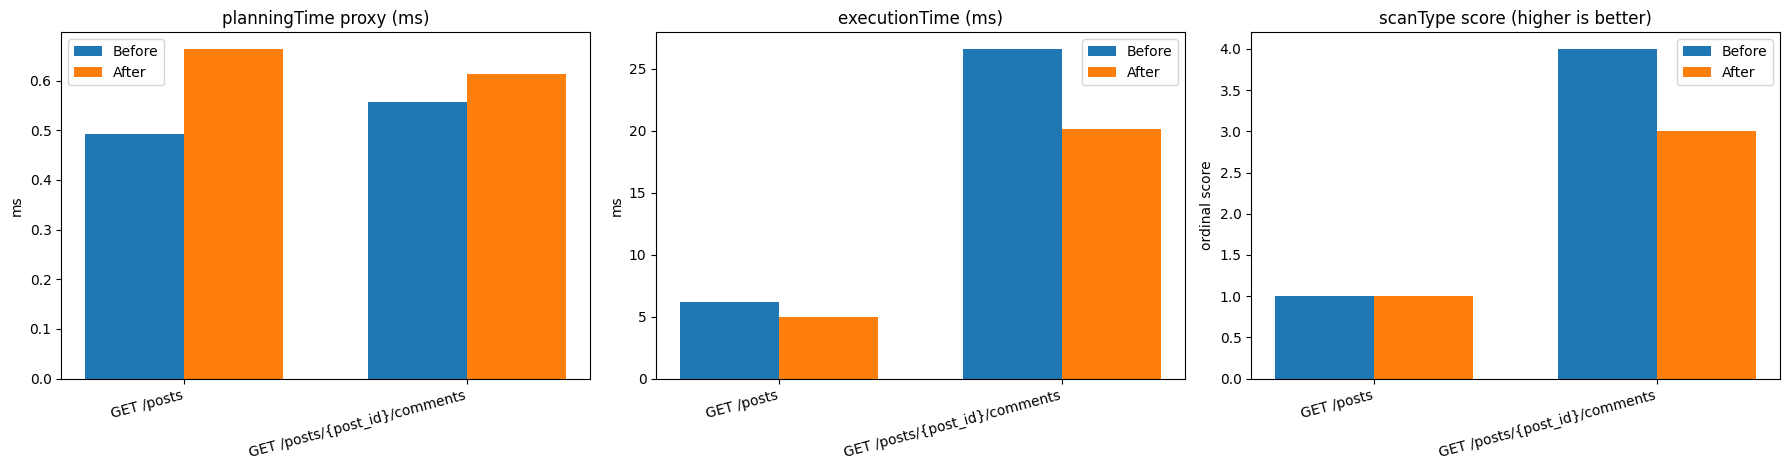

### Step 1: Auto-discovered API endpoint timings (top routes)

| Discovered Route | Resolved Path | Pre-index API Avg (ms) |
|---|---|---|
| /posts/{post_id}/comments | /posts/3025/comments | 99.838 |
| /posts/{post_id} | /posts/3025 | 50.218 |
| /posts | /posts?limit=20&offset=1512 | 39.525 |
| /members/search | /members/search?q=a | 18.422 |
| /isAuth | /isAuth | 12.469 |

### Step 2: Optimization targets selected

- list_comments
- list_posts

### Step 3: Before vs After latency comparison

| Endpoint | Layer | Before Avg (ms) | After Avg (ms) | Speedup (x) |
|---|---|---|---|---|
| GET /posts | SQL | 6.164 | 4.973 | 1.239 |
| GET /posts/{post_id}/comments | SQL | 26.619 | 20.172 | 1.320 |
| GET /posts | API | 31.097 | 32.927 | 0.944 |
| GET /posts/{post_id}/comments | API | 89.760 | 80.823 | 1.111 |

### Step 4: Before vs After planningTime, executionTime, scanType

| Query | Before planningTime (ms) | After planningTime (ms) | Before executionTime (ms) | After executionTime (ms) | Before scanType | After scanType |
|---|---|---|---|---|---|---|
| GET /posts | 0.492 | 0.664 | 6.164 | 4.973 | ALL | ALL |
| GET /posts/{post_id}/comments | 0.556 | 0.613 | 26.619 | 20.172 | ref | range |

Planning metric note: using `EXPLAIN` wall-time proxy in MySQL.

Saved artifact: `performance/index_benchmark_results.json`

{'db_config': {'host': 'localhost',
  'user': 'root',
  'database': 'college_social_media'},
 'benchmark_params': {'iterations': 40,
  'warmup': 5,
  'limit': 20,
  'offset': 1512,
  'comment_post_id': 3025,
  'auto_identified_slowest': ['list_comments', 'list_posts']},
 'planning_metric_method': 'MySQL EXPLAIN wall-time proxy',
 'discovery': [{'route': '/posts/{post_id}/comments',
   'path': '/posts/3025/comments',
   'api_avg_ms': 99.838},
  {'route': '/posts/{post_id}', 'path': '/posts/3025', 'api_avg_ms': 50.218},
  {'route': '/posts',
   'path': '/posts?limit=20&offset=1512',
   'api_avg_ms': 39.525},
  {'route': '/members/search',
   'path': '/members/search?q=a',
   'api_avg_ms': 18.422},
  {'route': '/isAuth', 'path': '/isAuth', 'api_avg_ms': 12.469}],
 'stages': [{'stage': 'before_indexes',
   'indexes_enabled': False,
   'sql_ms': {'list_posts': {'avg_ms': 6.164,
     'median_ms': 4.674,
     'p95_ms': 10.393,
     'min_ms': 3.582,
     'max_ms': 11.02},
    'list_comments': 

In [25]:
# Benchmark workflow: auto-discovery, selective indexing, and MySQL-compatible metrics.
import matplotlib.pyplot as plt

hotspot_post_id = ensure_benchmark_data()
limit, offset = choose_benchmark_params()
post_id = hotspot_post_id


def get_session_headers():
    login_req = urlrequest.Request(
        f"{API_BASE}/login",
        data=json.dumps({"username": "rahul.sharma@iitgn.ac.in", "password": "password123"}).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urlrequest.urlopen(login_req, timeout=20) as resp:
        token = json.loads(resp.read().decode("utf-8"))["session_token"]
    return {"session-token": token, "Content-Type": "application/json"}


def discover_get_routes(limit, offset, post_id):
    with urlrequest.urlopen(f"{API_BASE}/openapi.json", timeout=20) as resp:
        openapi = json.loads(resp.read().decode("utf-8"))

    routes = []
    for path, methods in openapi.get("paths", {}).items():
        if "get" not in methods or path in {"/", "/docs", "/openapi.json", "/redoc", "/health"}:
            continue
        resolved = path.replace("{post_id}", str(post_id))
        if path == "/posts":
            resolved = f"{resolved}?limit={limit}&offset={offset}"
        elif "search" in path.lower():
            resolved = f"{resolved}?q=a"
        routes.append({"route": path, "path": resolved})
    routes.sort(key=lambda x: x["route"])
    return routes


def measure_api_path(path, headers, warmup, iterations):
    vals = []
    for _ in range(warmup):
        req = urlrequest.Request(f"{API_BASE}{path}", headers=headers, method="GET")
        with urlrequest.urlopen(req, timeout=20) as resp:
            _ = resp.read()
            if resp.status >= 400:
                raise RuntimeError(f"Warmup failed for {path}: HTTP {resp.status}")
    for _ in range(iterations):
        start = time.perf_counter()
        req = urlrequest.Request(f"{API_BASE}{path}", headers=headers, method="GET")
        with urlrequest.urlopen(req, timeout=20) as resp:
            payload = resp.read()
            if resp.status >= 400:
                raise RuntimeError(f"Benchmark failed for {path}: HTTP {resp.status} {payload}")
        vals.append((time.perf_counter() - start) * 1000.0)
    return round(statistics.mean(vals), 3)


def map_route_to_key(route):
    r = route.lower()
    if "comments" in r:
        return "list_comments"
    if "posts" in r:
        return "list_posts"
    return None


def estimate_explain_ms(sql, params, warmup=2, iterations=8):
    conn = get_db_connection()
    samples = []
    try:
        with conn.cursor() as cursor:
            for _ in range(warmup):
                cursor.execute("EXPLAIN " + sql, params)
                cursor.fetchall()
            for _ in range(iterations):
                start = time.perf_counter()
                cursor.execute("EXPLAIN " + sql, params)
                cursor.fetchall()
                samples.append((time.perf_counter() - start) * 1000.0)
    finally:
        conn.close()
    return round(statistics.mean(samples), 3)


def extract_scan_type(explain_rows):
    if not explain_rows:
        return "unknown"
    rank = {"ALL": 0, "index": 1, "range": 2, "ref": 3, "eq_ref": 4, "const": 5, "system": 6}
    types = [str(r.get("type")) for r in explain_rows if r.get("type") is not None]
    if not types:
        return "unknown"
    return min(types, key=lambda t: rank.get(t, -1))


# Stage A: route discovery and baseline endpoint timing.
set_indexes(False)
headers_auth = get_session_headers()
route_candidates = discover_get_routes(limit, offset, post_id)
api_discovery = []
for c in route_candidates:
    try:
        avg_ms = measure_api_path(c["path"], headers_auth, DISCOVERY_WARMUP, DISCOVERY_ITERATIONS)
        api_discovery.append({"route": c["route"], "path": c["path"], "api_avg_ms": avg_ms})
    except Exception:
        continue
api_discovery.sort(key=lambda x: x["api_avg_ms"], reverse=True)

auto_slowest = []
for r in api_discovery:
    key = map_route_to_key(r["route"])
    if key and key in AFTER_STAGE_INDEX_DEFS and key not in auto_slowest:
        auto_slowest.append(key)
if not auto_slowest:
    raise RuntimeError("No mappable slow endpoints discovered from API routes.")

# Stage B: before/after benchmark.
before = run_stage("before_indexes", False, limit, offset, post_id, auto_slowest)
after = run_stage("after_indexes", True, limit, offset, post_id, auto_slowest)

# MySQL planning metric proxy via timed EXPLAIN.
set_indexes(False, auto_slowest)
before_plan = {
    "list_posts": estimate_explain_ms(LIST_POSTS_SQL, (limit, offset)),
    "list_comments": estimate_explain_ms(LIST_COMMENTS_SQL, (post_id,)),
}
set_indexes(True, auto_slowest)
after_plan = {
    "list_posts": estimate_explain_ms(LIST_POSTS_SQL, (limit, offset)),
    "list_comments": estimate_explain_ms(LIST_COMMENTS_SQL, (post_id,)),
}

query_metrics = {
    "GET /posts": {
        "before": {
            "planning_ms": before_plan["list_posts"],
            "execution_ms": before["sql_ms"]["list_posts"]["avg_ms"],
            "scan_type": extract_scan_type(before["explain"]["list_posts"]),
        },
        "after": {
            "planning_ms": after_plan["list_posts"],
            "execution_ms": after["sql_ms"]["list_posts"]["avg_ms"],
            "scan_type": extract_scan_type(after["explain"]["list_posts"]),
        },
    },
    "GET /posts/{post_id}/comments": {
        "before": {
            "planning_ms": before_plan["list_comments"],
            "execution_ms": before["sql_ms"]["list_comments"]["avg_ms"],
            "scan_type": extract_scan_type(before["explain"]["list_comments"]),
        },
        "after": {
            "planning_ms": after_plan["list_comments"],
            "execution_ms": after["sql_ms"]["list_comments"]["avg_ms"],
            "scan_type": extract_scan_type(after["explain"]["list_comments"]),
        },
    },
}

speedup_summary = {
    "posts_sql_speedup": speedup(before["sql_ms"]["list_posts"]["avg_ms"], after["sql_ms"]["list_posts"]["avg_ms"]),
    "comments_sql_speedup": speedup(before["sql_ms"]["list_comments"]["avg_ms"], after["sql_ms"]["list_comments"]["avg_ms"]),
    "posts_api_speedup": speedup(before["api_ms"]["list_posts"]["avg_ms"], after["api_ms"]["list_posts"]["avg_ms"]),
    "comments_api_speedup": speedup(before["api_ms"]["list_comments"]["avg_ms"], after["api_ms"]["list_comments"]["avg_ms"]),
    "posts_planning_speedup": speedup(before_plan["list_posts"], after_plan["list_posts"]),
    "comments_planning_speedup": speedup(before_plan["list_comments"], after_plan["list_comments"]),
}

# Render comparison tables.
disc_headers = ["Discovered Route", "Resolved Path", "Pre-index API Avg (ms)"]
disc_table = ["| " + " | ".join(disc_headers) + " |", "|" + "|".join(["---"] * len(disc_headers)) + "|"]
for d in api_discovery[:10]:
    disc_table.append("| " + " | ".join([d["route"], d["path"], fmt(d["api_avg_ms"])]) + " |")

lat_rows = [
    ["GET /posts", "SQL", before["sql_ms"]["list_posts"]["avg_ms"], after["sql_ms"]["list_posts"]["avg_ms"], speedup_summary["posts_sql_speedup"]],
    ["GET /posts/{post_id}/comments", "SQL", before["sql_ms"]["list_comments"]["avg_ms"], after["sql_ms"]["list_comments"]["avg_ms"], speedup_summary["comments_sql_speedup"]],
    ["GET /posts", "API", before["api_ms"]["list_posts"]["avg_ms"], after["api_ms"]["list_posts"]["avg_ms"], speedup_summary["posts_api_speedup"]],
    ["GET /posts/{post_id}/comments", "API", before["api_ms"]["list_comments"]["avg_ms"], after["api_ms"]["list_comments"]["avg_ms"], speedup_summary["comments_api_speedup"]],
]
lat_headers = ["Endpoint", "Layer", "Before Avg (ms)", "After Avg (ms)", "Speedup (x)"]
lat_table = ["| " + " | ".join(lat_headers) + " |", "|" + "|".join(["---"] * len(lat_headers)) + "|"]
for r in lat_rows:
    lat_table.append("| " + " | ".join([str(r[0]), str(r[1]), fmt(r[2]), fmt(r[3]), fmt(r[4])]) + " |")

metric_headers = ["Query", "Before planningTime (ms)", "After planningTime (ms)", "Before executionTime (ms)", "After executionTime (ms)", "Before scanType", "After scanType"]
metric_table = ["| " + " | ".join(metric_headers) + " |", "|" + "|".join(["---"] * len(metric_headers)) + "|"]
for q, vals in query_metrics.items():
    b = vals["before"]
    a = vals["after"]
    metric_table.append("| " + " | ".join([q, fmt(b["planning_ms"]), fmt(a["planning_ms"]), fmt(b["execution_ms"]), fmt(a["execution_ms"]), str(b["scan_type"]), str(a["scan_type"])]) + " |")

# Plot planning/execution/scan graphs.
labels = list(query_metrics.keys())
x = list(range(len(labels)))
bar_w = 0.35
before_plan_vals = [query_metrics[k]["before"]["planning_ms"] for k in labels]
after_plan_vals = [query_metrics[k]["after"]["planning_ms"] for k in labels]
before_exec_vals = [query_metrics[k]["before"]["execution_ms"] for k in labels]
after_exec_vals = [query_metrics[k]["after"]["execution_ms"] for k in labels]
scan_rank = {"unknown": 0, "ALL": 1, "index": 2, "range": 3, "ref": 4, "eq_ref": 5, "const": 6, "system": 7}
before_scan_score = [scan_rank.get(str(query_metrics[k]["before"]["scan_type"]), 0) for k in labels]
after_scan_score = [scan_rank.get(str(query_metrics[k]["after"]["scan_type"]), 0) for k in labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
axes[0].bar([i - bar_w / 2 for i in x], before_plan_vals, width=bar_w, label="Before")
axes[0].bar([i + bar_w / 2 for i in x], after_plan_vals, width=bar_w, label="After")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15, ha="right")
axes[0].set_title("planningTime proxy (ms)")
axes[0].set_ylabel("ms")
axes[0].legend()

axes[1].bar([i - bar_w / 2 for i in x], before_exec_vals, width=bar_w, label="Before")
axes[1].bar([i + bar_w / 2 for i in x], after_exec_vals, width=bar_w, label="After")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15, ha="right")
axes[1].set_title("executionTime (ms)")
axes[1].set_ylabel("ms")
axes[1].legend()

axes[2].bar([i - bar_w / 2 for i in x], before_scan_score, width=bar_w, label="Before")
axes[2].bar([i + bar_w / 2 for i in x], after_scan_score, width=bar_w, label="After")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=15, ha="right")
axes[2].set_title("scanType score (higher is better)")
axes[2].set_ylabel("ordinal score")
axes[2].legend()

plt.tight_layout()
plt.show()

results = {
    "db_config": {"host": DB_HOST, "user": DB_USER, "database": DB_NAME},
    "benchmark_params": {"iterations": ITERATIONS, "warmup": WARMUP, "limit": limit, "offset": offset, "comment_post_id": post_id, "auto_identified_slowest": auto_slowest},
    "planning_metric_method": "MySQL EXPLAIN wall-time proxy",
    "discovery": api_discovery,
    "stages": [before, after],
    "speedup": speedup_summary,
    "query_metrics": query_metrics,
}

out_dir = Path("performance")
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "index_benchmark_results.json"
out_file.write_text(json.dumps(results, indent=2), encoding="utf-8")

display(Markdown("### Step 1: Auto-discovered API endpoint timings (top routes)\n\n" + "\n".join(disc_table)))
display(Markdown("### Step 2: Optimization targets selected\n\n- " + "\n- ".join(auto_slowest)))
display(Markdown("### Step 3: Before vs After latency comparison\n\n" + "\n".join(lat_table)))
display(Markdown("### Step 4: Before vs After planningTime, executionTime, scanType\n\n" + "\n".join(metric_table)))
display(Markdown("Planning metric note: using `EXPLAIN` wall-time proxy in MySQL."))
display(Markdown(f"Saved artifact: `performance/index_benchmark_results.json`"))

results

## 5) Video Demonstration Link

Add your hosted 3-5 minute demo link here (YouTube unlisted or open Drive link):
- `<PASTE_VIDEO_LINK_HERE>`

## 6) Conclusion

- Module B integrates secure local APIs, RBAC enforcement, and auditable DB operations.
- Indexing/benchmarking pipeline is implemented with before-vs-after quantitative evidence.
- Remaining result analysis can be expanded with larger datasets if needed.